<a href="https://colab.research.google.com/github/mweb4100/CS4410-Homework/blob/main/Homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer()

In [2]:
print("Data shape:", breast_cancer.data.shape)
print("Target shape:", breast_cancer.target.shape)
print("Target names:", breast_cancer.target_names)

Data shape: (569, 30)
Target shape: (569,)
Target names: ['malignant' 'benign']


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    breast_cancer.data,
    breast_cancer.target,
    random_state=11
)

In [4]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (426, 30)
X_test shape: (143, 30)
y_train shape: (426,)
y_test shape: (143,)


In [5]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

In [6]:
nb.fit(X_train, y_train)

GaussianNB()

In [7]:
predicted = nb.predict(X_test)

print("Predicted:", predicted[:20])
print("Expected: ", y_test[:20])

Predicted: [0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0]
Expected:  [0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0]


In [8]:
accuracy = nb.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.951048951048951


In [9]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, predicted)

print(conf_matrix)

[[44  6]
 [ 1 92]]


In [10]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predicted,
    target_names=breast_cancer.target_names
))

              precision    recall  f1-score   support

   malignant       0.98      0.88      0.93        50
      benign       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



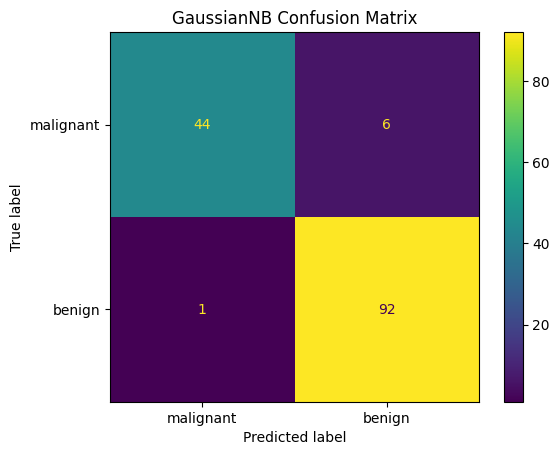

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=breast_cancer.target_names
)

display.plot()
plt.title("GaussianNB Confusion Matrix")
plt.show()

In [12]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kfold = KFold(
    n_splits=10,
    random_state=11,
    shuffle=True
)

scores = cross_val_score(
    estimator=nb,
    X=breast_cancer.data,
    y=breast_cancer.target,
    cv=kfold
)

print("Scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Scores: [0.96491228 0.9122807  0.94736842 0.89473684 0.96491228 0.94736842
 0.96491228 0.89473684 0.96491228 0.92857143]
Mean accuracy: 0.9384711779448622
Standard deviation: 0.02750305414538902


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

estimators = {
    'GaussianNB': nb,
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(
        solver='lbfgs',
        max_iter=10000
    ),
    'SVC': SVC(gamma='scale')
}

In [14]:
for estimator_name, estimator_object in estimators.items():
    scores = cross_val_score(
        estimator=estimator_object,
        X=breast_cancer.data,
        y=breast_cancer.target,
        cv=kfold
    )

    print(
        estimator_name,
        "Mean accuracy:",
        scores.mean(),
        "Standard deviation:",
        scores.std()
    )

GaussianNB Mean accuracy: 0.9384711779448622 Standard deviation: 0.02750305414538902
KNeighborsClassifier Mean accuracy: 0.9279135338345865 Standard deviation: 0.02005523998830162
LogisticRegression Mean accuracy: 0.950814536340852 Standard deviation: 0.030155034463240953
SVC Mean accuracy: 0.9191729323308271 Standard deviation: 0.035227300242783435
